In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../raw-data/jena_climate_2009_2016.csv"
)

print(f"Dimensiones: {df.shape}")
display(df.head())

Dimensiones: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [2]:
df["Date Time"] = pd.to_datetime(
    df["Date Time"],
    format="%d.%m.%Y %H:%M:%S"
)

data = df[["Date Time", "T (degC)"]].copy()

data.columns = ["fecha", "temperatura"]

print(data.isna().sum())
display(data.describe())

fecha          0
temperatura    0
dtype: int64


,fecha,temperatura
count,420551,420551.000000
mean,2012-12-30 06:26:51.498724,9.450147
min,2009-01-01 00:10:00,-23.010000
25%,2010-12-31 03:25:00,3.360000
50%,2012-12-30 06:20:00,9.420000
75%,2014-12-29 18:55:00,15.470000
max,2017-01-01 00:00:00,37.280000
std,NaN,8.423365


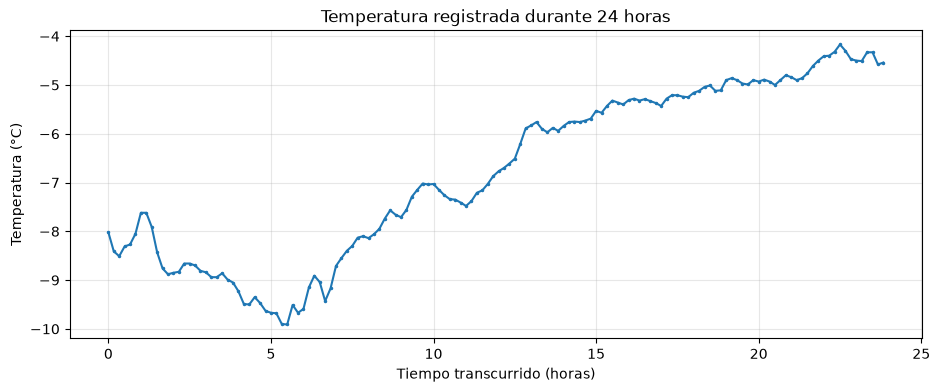

In [3]:
# Seleccionar 24 hs
ventana = data.iloc[:144].copy()

ventana["x"] = (
    ventana["fecha"] - ventana["fecha"].iloc[0]
).dt.total_seconds() / 3600


ventana["y"] = ventana["temperatura"]

plt.figure(figsize=(11, 4))

plt.plot(
    ventana["x"],
    ventana["y"],
    marker=".",
    markersize=3
)

plt.xlabel("Tiempo transcurrido (horas)")
plt.ylabel("Temperatura (°C)")
plt.title("Temperatura registrada durante 24 horas")
plt.grid(alpha=0.3)
plt.show()

In [4]:
# Cantidad de mediciones que se van a ocultar
n = len(ventana)
n_ocultos = round(n * 0.20)

# Generador aleatorio con semilla fija
rng = np.random.default_rng(42)

# Seleccionar índices aleatorios sin repetición
indices_ocultos = rng.choice(
    n,
    size=n_ocultos,
    replace=False
)

# Crear una copia para simular mediciones perdidas
datos = ventana.copy()
datos.loc[datos.index[indices_ocultos], "y"] = np.nan

print(f"Total de mediciones: {n}")
print(f"Mediciones ocultas: {n_ocultos}")
print(f"Mediciones disponibles: {datos['y'].notna().sum()}")

Total de mediciones: 144
Mediciones ocultas: 29
Mediciones disponibles: 115


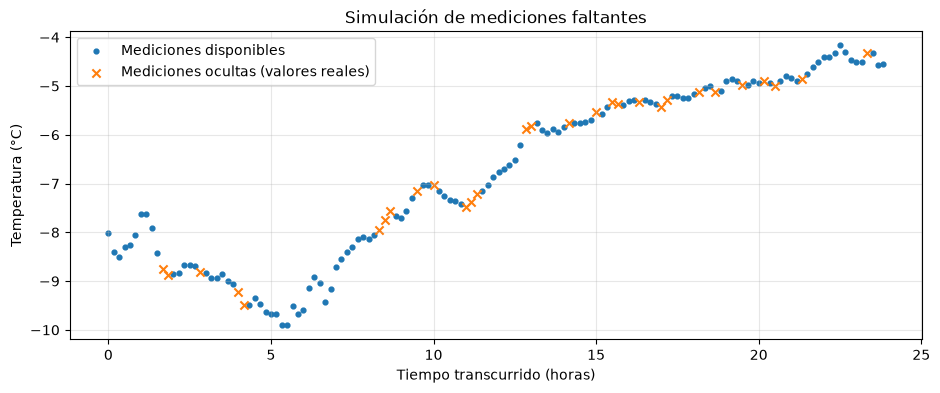

In [5]:
conocidos = datos["y"].notna()
faltantes = datos["y"].isna()

plt.figure(figsize=(11, 4))

plt.scatter(
    datos.loc[conocidos, "x"],
    datos.loc[conocidos, "y"],
    s=12,
    label="Mediciones disponibles"
)

plt.scatter(
    ventana.loc[faltantes, "x"],
    ventana.loc[faltantes, "y"],
    s=35,
    marker="x",
    label="Mediciones ocultas (valores reales)"
)

plt.xlabel("Tiempo transcurrido (horas)")
plt.ylabel("Temperatura (°C)")
plt.title("Simulación de mediciones faltantes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [6]:
# Seleccionar únicamente las mediciones disponibles
x_conocidos = datos.loc[conocidos, "x"].to_numpy()
y_conocidos = datos.loc[conocidos, "y"].to_numpy()

# Construir la matriz para un polinomio de grado 1
A = np.column_stack([
    np.ones(len(x_conocidos)),
    x_conocidos
])

# Calcular coeficientes por mínimos cuadrados
coeficientes, _, _, _ = np.linalg.lstsq(
    A,
    y_conocidos,
    rcond=None
)

a0, a1 = coeficientes

print(f"P1(x) = {a0:.6f} + ({a1:.6f})x")

P1(x) = -9.592070 + (0.233008)x


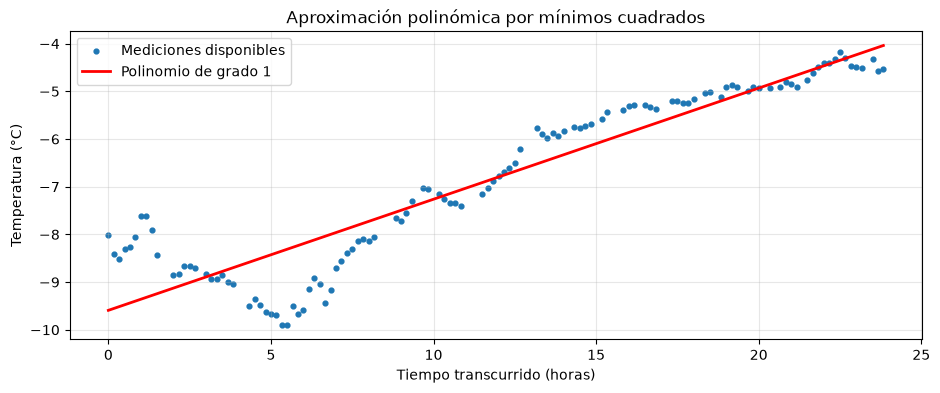

In [7]:
x_grafico = np.linspace(
    datos["x"].min(),
    datos["x"].max(),
    300
)

y_grafico = a0 + a1 * x_grafico

plt.figure(figsize=(11, 4))

plt.scatter(
    x_conocidos,
    y_conocidos,
    s=12,
    label="Mediciones disponibles"
)

plt.plot(
    x_grafico,
    y_grafico,
    color="red",
    linewidth=2,
    label="Polinomio de grado 1"
)

plt.xlabel("Tiempo transcurrido (horas)")
plt.ylabel("Temperatura (°C)")
plt.title("Aproximación polinómica por mínimos cuadrados")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
def ajustar_polinomio(x, y, grado):
    # Matriz de diseño: columnas 1, x, x², ..., x^grado
    A = np.column_stack([
        x**j for j in range(grado + 1)
    ])

    # Resolver el problema de mínimos cuadrados
    coeficientes, _, _, _ = np.linalg.lstsq(
        A, y, rcond=None
    )

    return coeficientes


def evaluar_polinomio(coeficientes, x):
    y_estimado = np.zeros_like(x, dtype=float)

    for j, a in enumerate(coeficientes):
        y_estimado += a * x**j

    return y_estimado

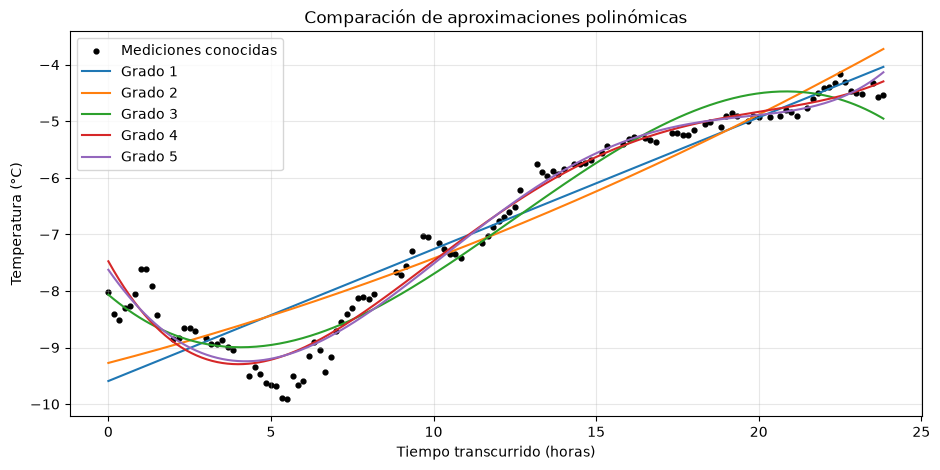

In [9]:
x_grafico = np.linspace(0, datos["x"].max(), 300)

plt.figure(figsize=(11, 5))

plt.scatter(
    x_conocidos,
    y_conocidos,
    s=12,
    color="black",
    label="Mediciones conocidas"
)

# cambiar rango a range(1,10) para evaluar polinomios de grado 9
for grado in range(1, 6):
    coeficientes = ajustar_polinomio(
        x_conocidos,
        y_conocidos,
        grado
    )

    y_grafico = evaluar_polinomio(
        coeficientes,
        x_grafico
    )

    plt.plot(
        x_grafico,
        y_grafico,
        label=f"Grado {grado}"
    )

plt.xlabel("Tiempo transcurrido (horas)")
plt.ylabel("Temperatura (°C)")
plt.title("Comparación de aproximaciones polinómicas")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
# Valores de x donde ocultamos las temperaturas
x_ocultos = datos.loc[faltantes, "x"].to_numpy()

# Valores reales, conservados para validar
y_reales = ventana.loc[faltantes, "y"].to_numpy()

resultados = []

# cambiar rango a range(1,10) para evaluar polinomios de grado 9
for grado in range(1, 6):
    # Ajustar usando exclusivamente los datos conocidos
    coeficientes = ajustar_polinomio(
        x_conocidos, y_conocidos, grado
    )

    # Reconstruir los valores ocultos
    y_estimados = evaluar_polinomio(
        coeficientes, x_ocultos
    )

    # Calcular errores de reconstrucción
    errores = y_reales - y_estimados

    mae = np.mean(np.abs(errores))
    mse = np.mean(errores**2)

    resultados.append({
        "Grado": grado,
        "MAE (°C)": mae,
        "MSE (°C²)": mse
    })

tabla_resultados = pd.DataFrame(resultados)

display(tabla_resultados.round(4))

,Grado,MAE (°C),MSE (°C²)
0,1,0.3478,0.1719
1,2,0.3837,0.2259
2,3,0.3453,0.1607
3,4,0.2225,0.0740
4,5,0.2154,0.0769


In [11]:
def diferencias_divididas(x, y):
    n = len(x)
    coeficientes = y.astype(float).copy()

    for j in range(1, n):
        for i in range(n - 1, j - 1, -1):
            coeficientes[i] = (
                (coeficientes[i] - coeficientes[i - 1])
                / (x[i] - x[i - j])
            )

    return coeficientes

In [12]:
def evaluar_newton(coeficientes, x_nodos, x):
    resultado = coeficientes[-1]

    for i in range(len(coeficientes) - 2, -1, -1):
        resultado = (
            resultado * (x - x_nodos[i])
            + coeficientes[i]
        )

    return resultado

In [13]:
def interpolar_newton(x_objetivo, x_conocidos, y_conocidos, n_nodos=4):
    # Distancias desde el punto faltante a los conocidos
    distancias = np.abs(x_conocidos - x_objetivo)

    # Seleccionar los cuatro nodos más cercanos
    indices = np.argsort(distancias)[:n_nodos]

    # Ordenarlos por x
    indices = indices[np.argsort(x_conocidos[indices])]

    x_nodos = x_conocidos[indices]
    y_nodos = y_conocidos[indices]

    # Calcular coeficientes del polinomio interpolante
    coeficientes = diferencias_divididas(x_nodos, y_nodos)

    # Evaluar el polinomio en el punto faltante
    return evaluar_newton(coeficientes, x_nodos, x_objetivo)

In [14]:
y_newton = np.array([
    interpolar_newton(x, x_conocidos, y_conocidos)
    for x in x_ocultos
])

errores_newton = y_reales - y_newton

mae_newton = np.mean(np.abs(errores_newton))
mse_newton = np.mean(errores_newton**2)

print(f"MAE Newton: {mae_newton:.4f} °C")
print(f"MSE Newton: {mse_newton:.4f} °C²")

MAE Newton: 0.0485 °C
MSE Newton: 0.0036 °C²


In [15]:
comparacion = tabla_resultados.copy()

comparacion["Método"] = comparacion["Grado"].apply(
    lambda grado: f"Mínimos cuadrados (grado {grado})"
)

comparacion = comparacion[
    ["Método", "MAE (°C)", "MSE (°C²)"]
]

comparacion = pd.concat([
    comparacion,
    pd.DataFrame([{
        "Método": "Newton (4 nodos)",
        "MAE (°C)": mae_newton,
        "MSE (°C²)": mse_newton
    }])
], ignore_index=True)

display(
    comparacion.sort_values("MSE (°C²)").round(4)
)

,Método,MAE (°C),MSE (°C²)
5,Newton (4 nodos),0.0485,0.0036
3,Mínimos cuadrados (grado 4),0.2225,0.0740
4,Mínimos cuadrados (grado 5),0.2154,0.0769
2,Mínimos cuadrados (grado 3),0.3453,0.1607
0,Mínimos cuadrados (grado 1),0.3478,0.1719
1,Mínimos cuadrados (grado 2),0.3837,0.2259


In [16]:
comparacion.to_csv("../resultados/resultados_24h.csv", index=False)

In [17]:
print("Observaciones:", len(ventana))
print("Mediciones conocidas:", len(x_conocidos))
print("Mediciones ocultas:", len(x_ocultos))
print("Rango temporal:", ventana["fecha"].min(), "a", ventana["fecha"].max())

Observaciones: 144
Mediciones conocidas: 115
Mediciones ocultas: 29
Rango temporal: 2009-01-01 00:10:00 a 2009-01-02 00:00:00
